In [1]:
import h5py
import o2sclpy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
plt.rc('font', size=12.0)

In [199]:
models = ['np']
x_name = ['a', 'alpha', 'param_S', 'param_L', '', 'trans1', '', 
           'trans2', '']
for k in range(len(models)):
    if models[k] == 'mp' or models[k] == 'np':
        x_name[4], x_name[6], x_name[8] = 'exp1', 'exp2', 'exp3'
    else:
        x_name[4], x_name[6], x_name[8] = 'csq1', 'csq2', 'csq3'
x_name = x_name + ['M_chirp_det', 'q']
y_name = [f"R_{i}" for i in range(100)]
y_name = y_name + ['M_max', 'dpdM', 'I1', 'I2']

dir = '/home/anik/bamr/out/aff_inv/'
mchain = h5py.File(dir + models[0] + '_all', 'r')['markov_chain_0']
nrow, data = mchain['nlines'][0], mchain['data']

x_ncol, y_ncol = len(x_name), len(y_name)
x, y = np.zeros((x_ncol, nrow)), np.zeros((y_ncol, nrow))

for i in range(x_ncol):
    x[i] = data[x_name[i]]
for i in range(y_ncol):
    y[i] = data[y_name[i]]

x, y = x.T, y.T
x_tr, x_ts, y_tr, y_ts = train_test_split(x, y, test_size=0.1, random_state=42)

In [200]:
DTR=DecisionTreeRegressor(criterion='absolute_error', random_state=42)
RFR=RandomForestRegressor(criterion='absolute_error', random_state=42)
scoring='neg_mean_squared_error'
cv, n_jobs=5, -1
hp_dtr = {
    'max_depth': [5, 10, 15, 20, 25, 30, 35, None],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 3],
}

gs_dtr = GridSearchCV(estimator=RFR, param_grid=hp_dtr,
                       scoring=scoring, cv=cv, n_jobs=n_jobs,
                       return_train_score=True, verbose=2)
gs_dtr.fit(x_tr, y_tr)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


KeyboardInterrupt: 

In [4]:
best_dtr = gs_dtr.best_estimator_
best_hps = gs_dtr.best_params_
print(f"Best HPs for DTR-1: {best_hps}")
y_pr = best_dtr.predict(x_ts)
mse = mean_squared_error(y_ts, y_pr)
mae = mean_absolute_error(y_ts, y_pr)
r2 = r2_score(y_ts, y_pr)
print(f"MSE: {mse}, MAE: {mae}, R2: {r2}")

Best HPs for DTR-1: {'max_depth': 5}
MSE: 3.116457055808384, MAE: 0.3912681339272357, R2: 0.559669276875439


In [76]:
DTR=DecisionTreeRegressor(random_state=42, criterion='absolute_error')
DTR.fit(x_tr, y_tr)
y_pr = DTR.predict(x_ts)
mse = mean_squared_error(y_ts, y_pr)
mae = mean_absolute_error(y_ts, y_pr)
r2 = r2_score(y_ts, y_pr)
print(f"DTR: mse={mse}, mae={mae}, r2={r2}")

DTR: mse=47757118150.78048, mae=969.0437307061197, r2=0.3723848559543115


[11.19593833 12.22081527 11.5469656  ... 10.8307929  11.3353122
 12.20948517]


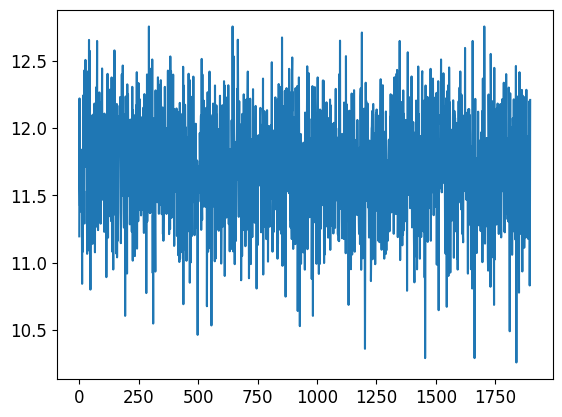

In [123]:
#from scipy.interpolate import interp1d

# Assuming y_pr is already defined
rd = y_pr[:, 0:100]  # Step 1: Get the first 100 columns
m_max = y_pr[:, 100]  # Step 2: Get the 101st column

# Step 3: Create gm and find the index of the first element in gm greater than m_max[i]
gm = np.linspace(0.2, 3.0, 100)
i_max = np.array([np.where(gm > m_max[i])[0][0] for i in range(len(m_max))])

# Initialize r_max to store results
r_max = np.zeros_like(m_max)

# Step 4-7: Loop through each row
for i in range(y_pr.shape[0]):
    # Step 5: m contains the first i_max[i] elements of gm
    m = gm[:i_max[i]]
    
    # Step 6: r contains the first len(m) elements of rd[i], which are all nonzeros
    r = rd[i][:len(m)]
    
    # Step 7: Linearly extrapolate r_max[i] from the m-r curve
    r_max[i] = np.interp(m_max[i], m, r)

# r_max now contains the extrapolated values
print(r_max)

plt.plot(r_max)
plt.show()

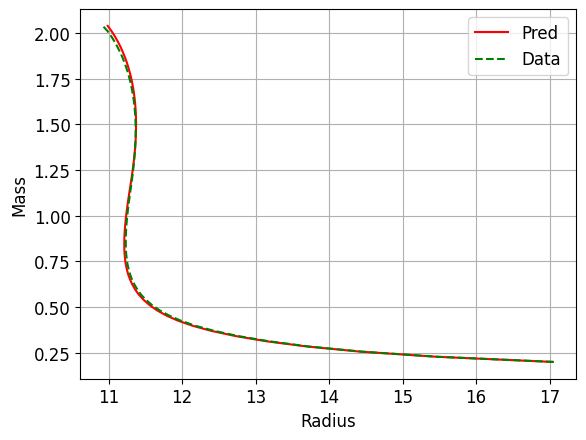

In [198]:
# Get rd and m_max
rd = y_pr[:, 0:100]
rd2 = y_ts[:, 0:100]
m_max = y_pr[:, 100]
m_max2 = y_ts[:, 100]

# Find i_max
i_max = np.array([np.where(gm > m_max[i])[0][0] for i in range(len(m_max))])
i_max2 = np.array([np.where(gm > m_max2[i])[0][0] for i in range(len(m_max2))])

# Select a random row index
random_index = np.random.randint(0, y_pr.shape[0])

# Extract m and r for the selected row
m = gm[:i_max[random_index]]
m2 = gm[:i_max2[random_index]]
r = rd[random_index][:len(m)]
r2 = rd2[random_index][:len(m2)]

# Plot m against r
plt.plot(r, m, label='Pred', c='r')
plt.plot(r2, m2, label='Data', c='g', ls='--')
plt.xlabel('Radius')
plt.ylabel('Mass')
plt.grid(True)
plt.legend()
plt.show()